In [34]:
"""
tridence task
SANCHIT LUTHRA
102303486
"""


'\ntridence task\nSANCHIT LUTHRA\n102303486\n'

simple thing we make a grid of  weight ,bais and gatescore by acc to input and output feature and first its empty and reselt parameter put number in it  then
1) we take sigmoid of gate score (0 means = kill this weight,
                                  1 means = keep this weight)
2) we see if that number pass the threshold or not
3) then we multiply weight and gates
4) then we apply simple liner formula--> (output=x*pruned_weights +bais)

In [58]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class PrunableLinear(nn.Module):
    def __init__(self, in_features, out_features):
        super(PrunableLinear, self).__init__()
        self.weight = nn.Parameter(torch.Tensor(out_features, in_features))
        self.bias = nn.Parameter(torch.Tensor(out_features))
        self.gate_scores = nn.Parameter(torch.Tensor(out_features, in_features))# one per weight  and control whihc weight to prune and which to not
        self.reset_parameters()

    def reset_parameters(self):# put number in these grids
        nn.init.kaiming_uniform_(self.weight, a=5**0.5)#Initialize random weight
        nn.init.constant_(self.bias, 0)#Initialize 0 to bais
        nn.init.constant_(self.gate_scores, 1.0)# initialize 1 to gates all
    def forward(self, x):
        gates = torch.sigmoid(self.gate_scores)
        if not self.training:
            gates = gates * (gates >= 1e-2).float()
        pruned_weights = self.weight * gates
        return F.linear(x, pruned_weights, self.bias)


# mlp model (multi layer perceptron) as core probelm state to use thiseedforward network

In [50]:

import torch.nn as nn
import torch.nn.functional as F

class CustomNet(nn.Module):# all fully connnected layers
    def __init__(self):
        super(CustomNet, self).__init__()
        self.fc1 = PrunableLinear(3 * 32 * 32, 512)# basic taking RGB and heihgt and width 32
        self.fc2 = PrunableLinear(512, 256)
        self.fc3 = PrunableLinear(256, 10)# CIFAR-10 has 10 clases so

    def forward(self, x):
        x = x.view(x.size(0), -1)  # flatten
        x = F.relu(self.fc1(x))#relu activation function used
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x


**L1 norm **
sigmoid make sure everything is in (0,1)

In [59]:
def get_sparsity_loss(model):
    sparsity_loss = 0
    for module in model.modules():
        if isinstance(module, PrunableLinear):# check only prunable layer
            sparsity_loss += torch.sum(torch.sigmoid(module.gate_scores))#add all gate score in sparsity loss
    return sparsity_loss

downloading and setting train_loder and test_loder in CIFAR-10

In [52]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])
train_dataset = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

In [63]:
def test(model, device, test_loader):
    model.eval()
    correct, total_gates, pruned_gates = 0, 0, 0
    with torch.no_grad():
        for data, target in test_loader:# loop through test images one batch at a time
            data, target = data.to(device), target.to(device)
            output = model(data)
            pred = output.argmax(dim=1, keepdim=True)#pick the class with highest score
            correct += pred.eq(target.view_as(pred)).sum().item()
    for module in model.modules():
        if isinstance(module, PrunableLinear):
            gates = torch.sigmoid(module.gate_scores).flatten()
            total_gates += gates.numel()
            pruned_gates += (gates < 1e-2).sum().item()
    accuracy = 100. * correct / len(test_loader.dataset)
    sparsity_pct = 100. * pruned_gates / total_gates if total_gates > 0 else 0
    return accuracy, sparsity_pct, []


def train(model, device, train_loader, optimizer, epoch, target_lambda, total_epochs):
    model.train()
    warmup_epochs = 3#  first 3 epochs = no pruning , just learn
    if epoch <= warmup_epochs:
        current_lambda = 0.0  #
    else:
        progress = (epoch - warmup_epochs) / (total_epochs - warmup_epochs)
        current_lambda = target_lambda * progress

    for batch_idx, (data, target) in enumerate(train_loader):# loop through training batches
        data, target = data.to(device), target.to(device)
        optimizer.zero_grad()
        output = model(data)
        ce_loss = F.cross_entropy(output, target)
        sparsity_loss = get_sparsity_loss(model)
        loss = ce_loss + (current_lambda * sparsity_loss)# total loss = accuracyloss + pruning
        if torch.isnan(loss):
            return
        loss.backward()
        torch.nn.utils.clip_grad_norm_(#  # clip gradients of weights only not gate_scores
            [p for n, p in model.named_parameters() if 'gate_scores' not in n],
            max_norm=1.0
        )
        optimizer.step()
        if batch_idx % 200 == 0:
            print(f'Epoch {epoch} | CE: {ce_loss.item():.4f} | Sparsity L: {sparsity_loss.item():.0f} | Active Lambda: {current_lambda:.2e}')

In [64]:

print("\n--- Running Final Training with Warm-up & Annealing ---")
lambdas = {'Low': 2e-6, 'Medium': 8e-6, 'High': 2e-5}
epochs = 10
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
results = {}
for name, target_lambda in lambdas.items():
    print(f"\n>> Training: {name} Sparsity (Target Lambda={target_lambda})")
    model = CustomNet().to(device)
    gate_params = [p for n, p in model.named_parameters() if 'gate_scores' in n]
    other_params = [p for n, p in model.named_parameters() if 'gate_scores' not in n]

    optimizer = torch.optim.Adam([# adam wiht dynamic learning rate
        {'params': other_params, 'lr': 0.001, 'weight_decay': 1e-4},
        {'params': gate_params, 'lr': 0.01, 'weight_decay': 0.0}
    ])

    for epoch in range(1, epochs + 1):
        train(model, device, train_loader, optimizer, epoch, target_lambda, epochs)
        acc, spar, _ = test(model, device, test_loader)
        print(f"   Epoch {epoch} | Accuracy: {acc:.2f}% | Sparsity: {spar:.2f}%")

    results[name] = (acc, spar)
print("\n" + "="*50)
print(f"{'Lambda Value':<15} | {'Test Acc':<10} | {'Sparsity %':<15}")
print("-" * 50)
for name, (acc, spar) in results.items():
    print(f"{lambdas[name]:<15} | {acc:<10.2f} | {spar:<15.2f}")
print("="*50)


--- Running Final Training with Warm-up & Annealing ---

>> Training: Low Sparsity (Target Lambda=2e-06)
Epoch 1 | CE: 2.3021 | Sparsity L: 1247548 | Active Lambda: 0.00e+00
Epoch 1 | CE: 1.6956 | Sparsity L: 1233614 | Active Lambda: 0.00e+00
Epoch 1 | CE: 1.5143 | Sparsity L: 1220486 | Active Lambda: 0.00e+00
Epoch 1 | CE: 1.6561 | Sparsity L: 1206877 | Active Lambda: 0.00e+00
   Epoch 1 | Accuracy: 47.09% | Sparsity: 0.00%
Epoch 2 | CE: 1.2967 | Sparsity L: 1194764 | Active Lambda: 0.00e+00
Epoch 2 | CE: 1.3586 | Sparsity L: 1180768 | Active Lambda: 0.00e+00
Epoch 2 | CE: 1.3070 | Sparsity L: 1165772 | Active Lambda: 0.00e+00
Epoch 2 | CE: 1.2565 | Sparsity L: 1150346 | Active Lambda: 0.00e+00
   Epoch 2 | Accuracy: 49.20% | Sparsity: 0.00%
Epoch 3 | CE: 1.4739 | Sparsity L: 1136430 | Active Lambda: 0.00e+00
Epoch 3 | CE: 1.3133 | Sparsity L: 1122041 | Active Lambda: 0.00e+00
Epoch 3 | CE: 1.5082 | Sparsity L: 1106717 | Active Lambda: 0.00e+00
Epoch 3 | CE: 1.2732 | Sparsity L: 1091

Generating Final Gate Distribution Plot...


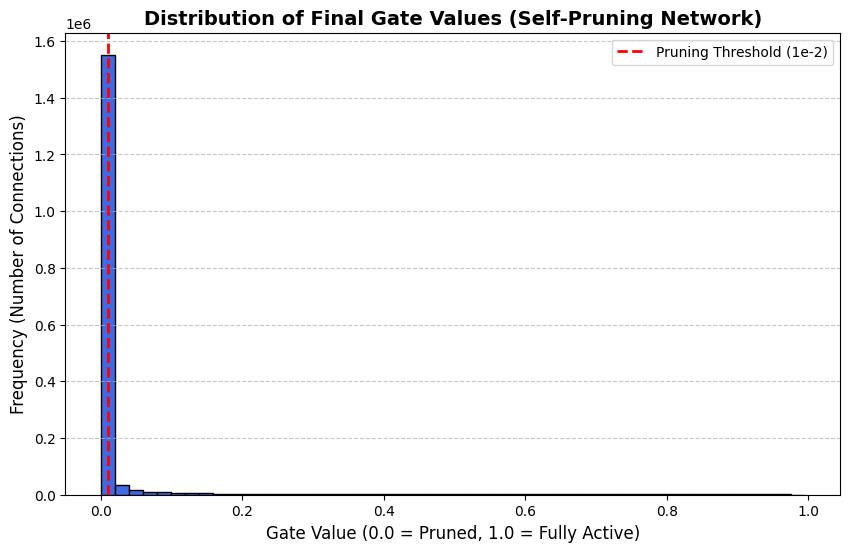

In [65]:
import matplotlib.pyplot as plt
import numpy as np
import torch

def plot_gate_distribution(model):
    all_gates = []
    for module in model.modules():
        if hasattr(module, 'gate_scores'):
            gates = torch.sigmoid(module.gate_scores).detach().cpu().numpy().flatten()
            all_gates.extend(gates)

    # Plot the histogram
    plt.figure(figsize=(10, 6))
    plt.hist(all_gates, bins=50, color='royalblue', edgecolor='black')
    plt.title("Distribution of Final Gate Values (Self-Pruning Network)", fontsize=14, fontweight='bold')
    plt.xlabel("Gate Value (0.0 = Pruned, 1.0 = Fully Active)", fontsize=12)
    plt.ylabel("Frequency (Number of Connections)", fontsize=12)
    plt.grid(axis='y', linestyle='--', alpha=0.7)

    # Highlight the zero spike
    plt.axvline(x=0.01, color='red', linestyle='dashed', linewidth=2, label='Pruning Threshold (1e-2)')
    plt.legend()

    # Save the plot so you can put it in your GitHub Repo!
    plt.savefig('gate_distribution.png', bbox_inches='tight')
    plt.show()

# Run this!
print("Generating Final Gate Distribution Plot...")
plot_gate_distribution(model)

this is another experimnet with gate_score initalize with 0


--- Running Final Training (Gates forced to 0.0) ---

>> Training: Low Sparsity (Target Lambda=2e-06)
Epoch 1 | CE: 2.3033 | Sparsity L: 853248 | Active Lambda: 0.00e+00
Epoch 1 | CE: 1.7907 | Sparsity L: 837506 | Active Lambda: 0.00e+00
Epoch 1 | CE: 1.7576 | Sparsity L: 823407 | Active Lambda: 0.00e+00
Epoch 1 | CE: 1.4784 | Sparsity L: 808626 | Active Lambda: 0.00e+00
   Epoch 1 | Accuracy: 47.64% | Sparsity: 0.00%
Epoch 2 | CE: 1.2877 | Sparsity L: 796471 | Active Lambda: 0.00e+00
Epoch 2 | CE: 1.7772 | Sparsity L: 782021 | Active Lambda: 0.00e+00
Epoch 2 | CE: 1.4517 | Sparsity L: 767827 | Active Lambda: 0.00e+00
Epoch 2 | CE: 1.3507 | Sparsity L: 754114 | Active Lambda: 0.00e+00
   Epoch 2 | Accuracy: 51.02% | Sparsity: 0.00%
Epoch 3 | CE: 1.1959 | Sparsity L: 742030 | Active Lambda: 0.00e+00
Epoch 3 | CE: 1.5464 | Sparsity L: 731078 | Active Lambda: 0.00e+00
Epoch 3 | CE: 1.4384 | Sparsity L: 718568 | Active Lambda: 0.00e+00
Epoch 3 | CE: 1.4309 | Sparsity L: 705956 | Active La

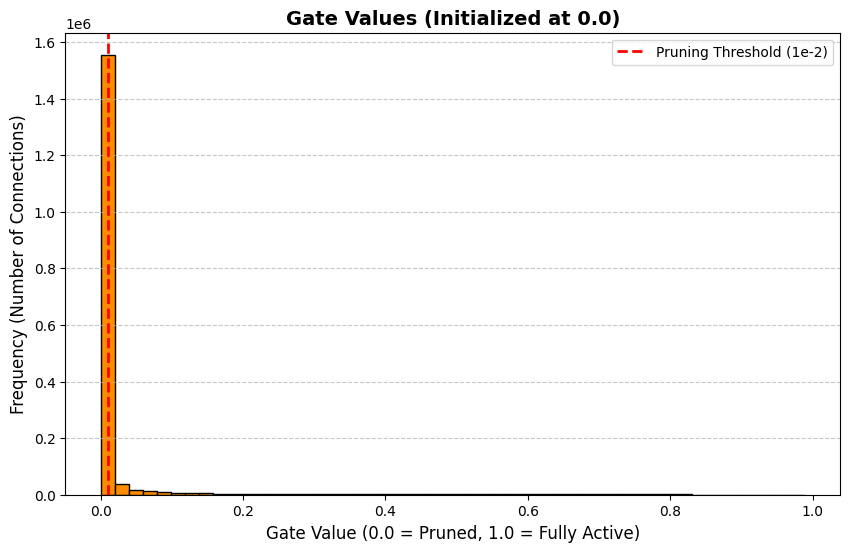

In [66]:
import matplotlib.pyplot as plt
import numpy as np
import torch

print("\n--- Running Final Training (Gates forced to 0.0) ---")

lambdas = {'Low': 2e-6, 'Medium': 8e-6, 'High': 2e-5}
epochs = 10
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

results = {}

for name, target_lambda in lambdas.items():
    print(f"\n>> Training: {name} Sparsity (Target Lambda={target_lambda})")

    model = CustomNet().to(device)


    gate_params = [p for n, p in model.named_parameters() if 'gate_scores' in n]
    other_params = [p for n, p in model.named_parameters() if 'gate_scores' not in n]

    # THE OVERRIDE: Force all gate scores to 0.0 in-place
    for p in gate_params:
        torch.nn.init.constant_(p, 0.0)

    optimizer = torch.optim.Adam([
        {'params': other_params, 'lr': 0.001, 'weight_decay': 1e-4},
        {'params': gate_params, 'lr': 0.01, 'weight_decay': 0.0}
    ])

    for epoch in range(1, epochs + 1):
        train(model, device, train_loader, optimizer, epoch, target_lambda, epochs)
        acc, spar, _ = test(model, device, test_loader)
        print(f"   Epoch {epoch} | Accuracy: {acc:.2f}% | Sparsity: {spar:.2f}%")

    results[name] = (acc, spar)

print("\n" + "="*50)
print(f"{'Lambda Value':<15} | {'Test Acc':<10} | {'Sparsity %':<15}")
print("-" * 50)
for name, (acc, spar) in results.items():
    print(f"{lambdas[name]:<15} | {acc:<10.2f} | {spar:<15.2f}")
print("="*50)

# --- 2. GENERATE THE NEW HISTOGRAM ---
print("\nGenerating Gate Distribution Plot for 0.0 Initialization...")
def plot_gate_distribution_zero(model):
    all_gates = []
    for module in model.modules():
        if hasattr(module, 'gate_scores'):
            gates = torch.sigmoid(module.gate_scores).detach().cpu().numpy().flatten()
            all_gates.extend(gates)

    plt.figure(figsize=(10, 6))
    plt.hist(all_gates, bins=50, color='darkorange', edgecolor='black') # Changed color to orange to tell them apart
    plt.title("Gate Values (Initialized at 0.0)", fontsize=14, fontweight='bold')
    plt.xlabel("Gate Value (0.0 = Pruned, 1.0 = Fully Active)", fontsize=12)
    plt.ylabel("Frequency (Number of Connections)", fontsize=12)
    plt.grid(axis='y', linestyle='--', alpha=0.7)

    plt.axvline(x=0.01, color='red', linestyle='dashed', linewidth=2, label='Pruning Threshold (1e-2)')
    plt.legend()

    # Saved as a different file name!
    plt.savefig('gate_distribution_0.png', bbox_inches='tight')
    plt.show()

# The 'model' variable here holds the High Sparsity model from the loop above
plot_gate_distribution_zero(model)